# Comparaison formelle des modèles NER

Modèles comparés :
- **SpaCy zero-shot** (`fr_core_news_lg`, sans fine-tuning)
- **SpaCy fine-tuné** (entraîné sur annotations Archelec)
- **GLiNER zero-shot** (`urchade/gliner_multi-v2.1`, seuil 0.5)
- **GLiNER fine-tuné** (checkpoint-800, focal loss, seuil optimal 0.5)
- **CamemBERT-NER** (fine-tuné stage 2, meilleure baseline supervisée)

Corpus de test : `test_before_2000.json` et `test_after_2000.json`  
Métriques : correspondance **exacte** (strict span match) — Precision, Recall, F1

In [1]:
import json
import pathlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

BASE = pathlib.Path('../data/results')
OUTDIR = pathlib.Path('../data/results/output_best_model/graphs')
OUTDIR.mkdir(parents=True, exist_ok=True)

ENTITY_TYPES = ['PER', 'ORG', 'LOC', 'MISC']
SPLITS = ['before_2000', 'after_2000']
OPT_THRESH = 0.5

In [2]:
# ── Chargement des métriques ────────────────────────────────────────────────

def load_gliner(split, thresh, variant='raw'):
    prefix = 'trained_' if variant == 'trained' else ''
    path = BASE / 'Gliner' / variant / f'{prefix}metrics_{split}_{thresh}.json'
    d = json.loads(path.read_text())
    return {
        'precision': d['exact']['precision'],
        'recall':    d['exact']['recall'],
        'f1':        d['exact']['f1'],
        'per_type':  {et: {'precision': d['per_type'][et]['precision'],
                            'recall':    d['per_type'][et]['recall'],
                            'f1':        d['per_type'][et]['f1'],
                            'support':   d['per_type'][et]['support']}
                      for et in ENTITY_TYPES if et in d['per_type']}
    }

def load_spacy(split, variant='raw'):
    folder = 'raw' if variant == 'raw' else 'trained'
    prefix = 'trained_' if variant == 'trained' else ''
    path = BASE / 'Spacy' / folder / f'{prefix}metrics_{split}.json'
    d = json.loads(path.read_text())
    return {
        'precision': d['exact']['precision'],
        'recall':    d['exact']['recall'],
        'f1':        d['exact']['f1'],
        'per_type':  {et: {'precision': d['per_type'][et]['precision'],
                            'recall':    d['per_type'][et]['recall'],
                            'f1':        d['per_type'][et]['f1'],
                            'support':   d['per_type'][et]['support']}
                      for et in ENTITY_TYPES if et in d['per_type']}
    }

def load_camembert(split):
    path = BASE / 'CamemBERT' / f'stage2_extended_metrics_{split}.json'
    d = json.loads(path.read_text())
    per_type = {}
    for et in ENTITY_TYPES:
        per_type[et] = {
            'precision': d.get(f'eval_precision_{et}', 0) / 100,
            'recall':    d.get(f'eval_recall_{et}', 0) / 100,
            'f1':        d.get(f'eval_f1_{et}', 0) / 100,
            'support':   None
        }
    return {
        'precision': d['eval_precision_global'] / 100,
        'recall':    d['eval_recall_global'] / 100,
        'f1':        d['eval_f1_global'] / 100,
        'per_type':  per_type
    }

# Charger tout au seuil optimal GLiNER = 0.5
data = {}
for split in SPLITS:
    data[split] = {
        'SpaCy zero-shot':   load_spacy(split, 'raw'),
        'SpaCy fine-tuné':   load_spacy(split, 'trained'),
        'GLiNER zero-shot':  load_gliner(split, OPT_THRESH, 'raw'),
        'GLiNER fine-tuné':  load_gliner(split, OPT_THRESH, 'trained'),
        'CamemBERT':         load_camembert(split),
    }

print('Données chargées :', {s: list(d.keys()) for s, d in data.items()})

Données chargées : {'before_2000': ['SpaCy zero-shot', 'SpaCy fine-tuné', 'GLiNER zero-shot', 'GLiNER fine-tuné', 'CamemBERT'], 'after_2000': ['SpaCy zero-shot', 'SpaCy fine-tuné', 'GLiNER zero-shot', 'GLiNER fine-tuné', 'CamemBERT']}


In [3]:
# ── Table 1 : métriques globales par split ──────────────────────────────────

MODEL_ORDER = ['SpaCy zero-shot', 'SpaCy fine-tuné',
               'GLiNER zero-shot', 'GLiNER fine-tuné', 'CamemBERT']

rows = []
for split in SPLITS:
    split_label = 'Avant 2000' if split == 'before_2000' else 'Après 2000'
    for model in MODEL_ORDER:
        m = data[split][model]
        rows.append({
            'Corpus': split_label,
            'Modèle': model,
            'Précision': f"{m['precision']:.3f}",
            'Rappel':    f"{m['recall']:.3f}",
            'F1':        f"{m['f1']:.3f}",
        })

table1 = pd.DataFrame(rows)
table1_pivot = table1.pivot(index='Modèle', columns='Corpus',
                             values=['Précision','Rappel','F1'])
table1_pivot = table1_pivot.reindex(MODEL_ORDER)

print('Table 1 — Métriques globales (correspondance exacte, seuil GLiNER=0.5)\n')
print(table1.to_string(index=False))

Table 1 — Métriques globales (correspondance exacte, seuil GLiNER=0.5)

    Corpus           Modèle Précision Rappel    F1
Avant 2000  SpaCy zero-shot     0.077  0.245 0.118
Avant 2000  SpaCy fine-tuné     0.292  0.208 0.243
Avant 2000 GLiNER zero-shot     0.157  0.336 0.214
Avant 2000 GLiNER fine-tuné     0.203  0.477 0.285
Avant 2000        CamemBERT     0.630  0.366 0.463
Après 2000  SpaCy zero-shot     0.098  0.377 0.156
Après 2000  SpaCy fine-tuné     0.038  0.018 0.025
Après 2000 GLiNER zero-shot     0.130  0.361 0.191
Après 2000 GLiNER fine-tuné     0.150  0.377 0.214
Après 2000        CamemBERT     0.194  0.185 0.189


In [4]:
# ── Table 2 : métriques combinées (moyenne pondérée par support) ─────────────
# Pour GLiNER et SpaCy on dispose du support → micro-moyenne exacte
# Pour CamemBERT pas de support → moyenne simple des deux splits

def global_support(split_data, model):
    """Support total = somme des supports des types (itère sur les clés présentes)."""
    s = 0
    for split in split_data.keys():
        for et in ENTITY_TYPES:
            sup = split_data[split][model]['per_type'].get(et, {}).get('support')
            if sup is not None:
                s += sup
    return s if s > 0 else None

combined_rows = []
for model in MODEL_ORDER:
    sup = global_support(data, model)
    if sup is not None:
        # micro-avg sur les deux splits
        tp_t = fp_t = fn_t = 0
        for sp in SPLITS:
            m = data[sp][model]
            sp_sup = sum(data[sp][model]['per_type'].get(et, {}).get('support', 0) or 0
                         for et in ENTITY_TYPES)
            tp = m['recall'] * sp_sup
            fn = sp_sup - tp
            fp = (tp / m['precision'] - tp) if m['precision'] > 0 else 0
            tp_t += tp; fp_t += fp; fn_t += fn
        p = tp_t / (tp_t + fp_t) if (tp_t + fp_t) > 0 else 0
        r = tp_t / (tp_t + fn_t) if (tp_t + fn_t) > 0 else 0
        f1 = 2*p*r/(p+r) if (p+r) > 0 else 0
        combined_rows.append({'Modèle': model, 'P': f'{p:.3f}', 'R': f'{r:.3f}',
                               'F1': f'{f1:.3f}', 'Note': 'micro-avg pondérée'})
    else:
        # CamemBERT : moyenne simple
        p = np.mean([data[sp][model]['precision'] for sp in SPLITS])
        r = np.mean([data[sp][model]['recall'] for sp in SPLITS])
        f1 = np.mean([data[sp][model]['f1'] for sp in SPLITS])
        combined_rows.append({'Modèle': model, 'P': f'{p:.3f}', 'R': f'{r:.3f}',
                               'F1': f'{f1:.3f}', 'Note': 'moy. simple (pas de support)'})

table2 = pd.DataFrame(combined_rows)
print('Table 2 — Métriques combinées (2 splits, correspondance exacte)\n')
print(table2.to_string(index=False))

Table 2 — Métriques combinées (2 splits, correspondance exacte)

          Modèle     P     R    F1                         Note
 SpaCy zero-shot 0.090 0.319 0.140           micro-avg pondérée
 SpaCy fine-tuné 0.175 0.101 0.128           micro-avg pondérée
GLiNER zero-shot 0.140 0.350 0.200           micro-avg pondérée
GLiNER fine-tuné 0.172 0.421 0.244           micro-avg pondérée
       CamemBERT 0.412 0.276 0.326 moy. simple (pas de support)


In [5]:
# ── Table 3 : F1 par type d'entité ──────────────────────────────────────────

per_type_rows = []
for split in SPLITS:
    split_label = 'Avant 2000' if split == 'before_2000' else 'Après 2000'
    for model in MODEL_ORDER:
        row = {'Corpus': split_label, 'Modèle': model}
        for et in ENTITY_TYPES:
            f1 = data[split][model]['per_type'].get(et, {}).get('f1', 0)
            row[et] = f'{f1:.3f}'
        per_type_rows.append(row)

table3 = pd.DataFrame(per_type_rows)
print('Table 3 — F1 par type d\'entité (correspondance exacte, seuil GLiNER=0.5)\n')
print(table3.to_string(index=False))

Table 3 — F1 par type d'entité (correspondance exacte, seuil GLiNER=0.5)

    Corpus           Modèle   PER   ORG   LOC  MISC
Avant 2000  SpaCy zero-shot 0.304 0.138 0.092 0.016
Avant 2000  SpaCy fine-tuné 0.521 0.178 0.413 0.000
Avant 2000 GLiNER zero-shot 0.348 0.189 0.152 0.178
Avant 2000 GLiNER fine-tuné 0.577 0.241 0.284 0.186
Avant 2000        CamemBERT 0.740 0.360 0.552 0.000
Après 2000  SpaCy zero-shot 0.178 0.207 0.238 0.000
Après 2000  SpaCy fine-tuné 0.036 0.027 0.000 0.000
Après 2000 GLiNER zero-shot 0.167 0.230 0.285 0.023
Après 2000 GLiNER fine-tuné 0.206 0.223 0.348 0.036
Après 2000        CamemBERT 0.240 0.215 0.050 0.000


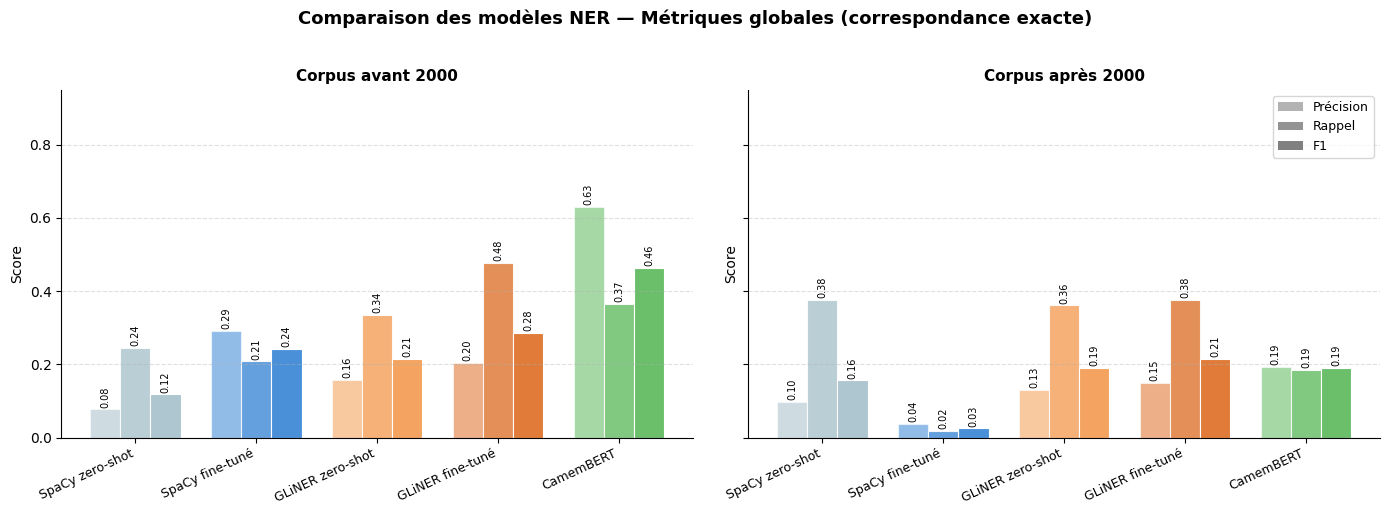

Sauvegardé : fig_ner_comparison_global.png


In [6]:
# ── Figure 1 : comparaison P/R/F1 par modèle et split ──────────────────────

COLORS = {
    'SpaCy zero-shot':   '#aec6cf',
    'SpaCy fine-tuné':   '#4a90d9',
    'GLiNER zero-shot':  '#f4a460',
    'GLiNER fine-tuné':  '#e07b39',
    'CamemBERT':         '#6bbf6b',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('Comparaison des modèles NER — Métriques globales (correspondance exacte)',
             fontsize=13, fontweight='bold', y=1.02)

for ax, split in zip(axes, SPLITS):
    split_label = 'Corpus avant 2000' if split == 'before_2000' else 'Corpus après 2000'
    x = np.arange(len(MODEL_ORDER))
    width = 0.25

    precs  = [data[split][m]['precision'] for m in MODEL_ORDER]
    recalls = [data[split][m]['recall'] for m in MODEL_ORDER]
    f1s    = [data[split][m]['f1'] for m in MODEL_ORDER]

    colors = [COLORS[m] for m in MODEL_ORDER]

    b1 = ax.bar(x - width, precs,  width, label='Précision', color=colors, alpha=0.6,
                edgecolor='white', linewidth=0.8)
    b2 = ax.bar(x,         recalls, width, label='Rappel',    color=colors, alpha=0.85,
                edgecolor='white', linewidth=0.8)
    b3 = ax.bar(x + width, f1s,    width, label='F1',        color=colors, alpha=1.0,
                edgecolor='white', linewidth=0.8)

    for bars in [b1, b2, b3]:
        for bar in bars:
            h = bar.get_height()
            if h > 0.01:
                ax.text(bar.get_x() + bar.get_width()/2, h + 0.005,
                        f'{h:.2f}', ha='center', va='bottom', fontsize=7, rotation=90)

    ax.set_title(split_label, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(MODEL_ORDER, rotation=25, ha='right', fontsize=9)
    ax.set_ylim(0, 0.95)
    ax.set_ylabel('Score', fontsize=10)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

# Légende commune (P/R/F1 distingués par opacité)
from matplotlib.patches import Patch
legend_elems = [
    Patch(facecolor='gray', alpha=0.6, label='Précision'),
    Patch(facecolor='gray', alpha=0.85, label='Rappel'),
    Patch(facecolor='gray', alpha=1.0, label='F1'),
]
axes[1].legend(handles=legend_elems, loc='upper right', fontsize=9)

plt.tight_layout()
fig.savefig(OUTDIR / 'fig_ner_comparison_global.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_ner_comparison_global.png')

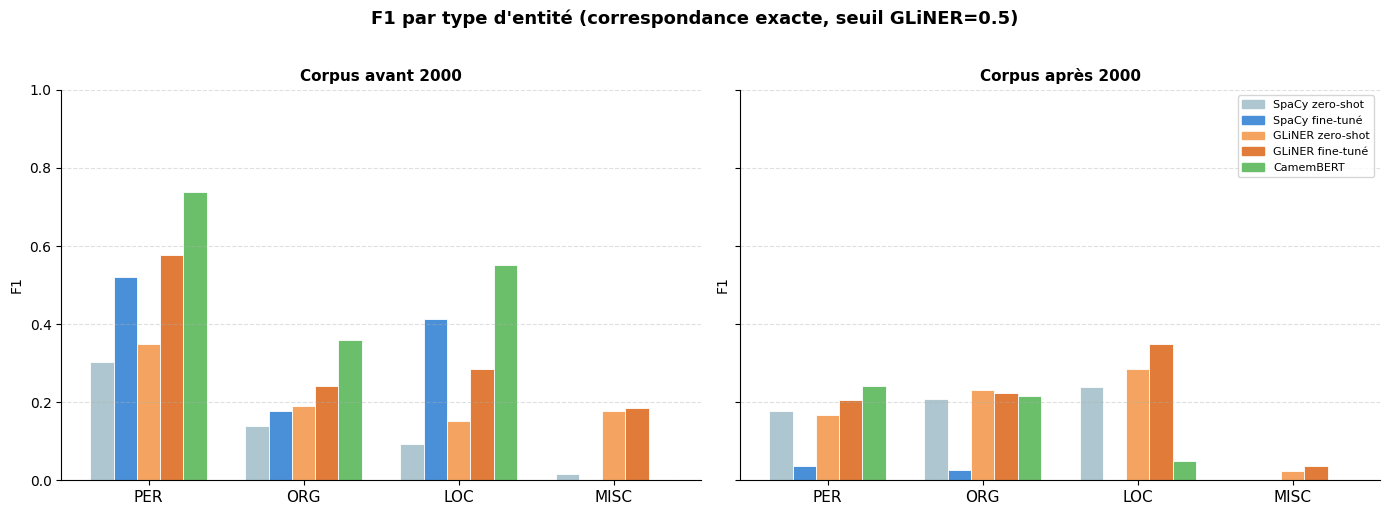

Sauvegardé : fig_ner_comparison_per_type.png


In [7]:
# ── Figure 2 : F1 par type d'entité ─────────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
fig.suptitle('F1 par type d\'entité (correspondance exacte, seuil GLiNER=0.5)',
             fontsize=13, fontweight='bold', y=1.02)

x = np.arange(len(ENTITY_TYPES))
n_models = len(MODEL_ORDER)
width = 0.15
offsets = np.linspace(-(n_models-1)/2 * width, (n_models-1)/2 * width, n_models)

for ax, split in zip(axes, SPLITS):
    split_label = 'Corpus avant 2000' if split == 'before_2000' else 'Corpus après 2000'
    for i, model in enumerate(MODEL_ORDER):
        f1s = [data[split][model]['per_type'].get(et, {}).get('f1', 0) for et in ENTITY_TYPES]
        ax.bar(x + offsets[i], f1s, width,
               label=model, color=COLORS[model], edgecolor='white', linewidth=0.6)

    ax.set_title(split_label, fontsize=11, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(ENTITY_TYPES, fontsize=11)
    ax.set_ylim(0, 1.0)
    ax.set_ylabel('F1', fontsize=10)
    ax.grid(axis='y', alpha=0.4, linestyle='--')
    ax.spines[['top','right']].set_visible(False)

handles = [mpatches.Patch(color=COLORS[m], label=m) for m in MODEL_ORDER]
axes[1].legend(handles=handles, loc='upper right', fontsize=8)

plt.tight_layout()
fig.savefig(OUTDIR / 'fig_ner_comparison_per_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_ner_comparison_per_type.png')

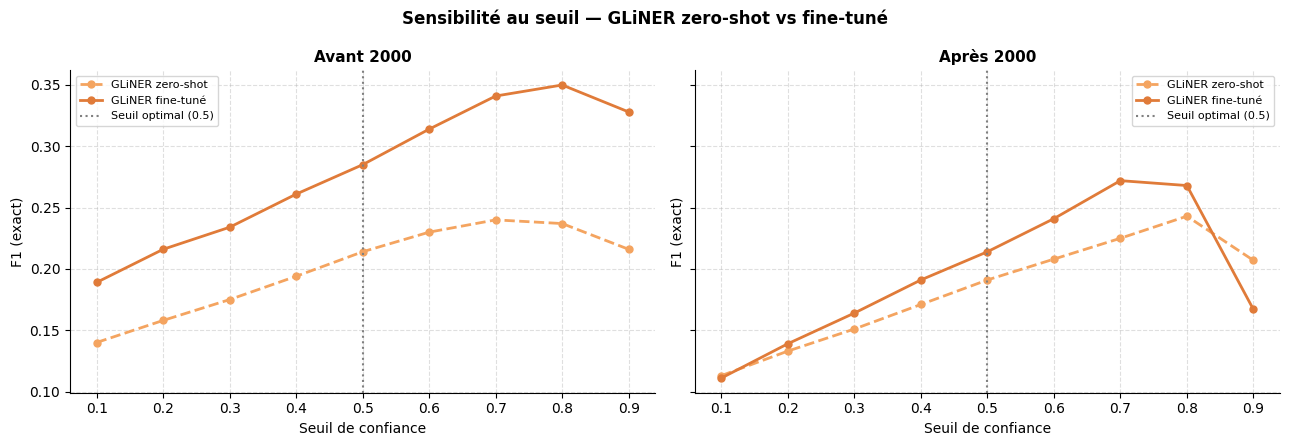

Sauvegardé : fig_ner_threshold_curve.png


In [8]:
# ── Figure 3 : courbe F1 vs seuil (GLiNER zero-shot vs fine-tuné) ───────────

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
fig.suptitle('Sensibilité au seuil — GLiNER zero-shot vs fine-tuné',
             fontsize=12, fontweight='bold')

for ax, split in zip(axes, SPLITS):
    split_label = 'Avant 2000' if split == 'before_2000' else 'Après 2000'
    for variant, label, color, ls in [
        ('raw',     'GLiNER zero-shot', '#f4a460', '--'),
        ('trained', 'GLiNER fine-tuné', '#e07b39', '-'),
    ]:
        f1s = []
        for t in thresholds:
            m = load_gliner(split, t, variant)
            f1s.append(m['f1'])
        ax.plot(thresholds, f1s, marker='o', color=color, linestyle=ls,
                linewidth=2, markersize=5, label=label)

    ax.axvline(OPT_THRESH, color='gray', linestyle=':', linewidth=1.5,
               label=f'Seuil optimal ({OPT_THRESH})')
    ax.set_title(split_label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Seuil de confiance', fontsize=10)
    ax.set_ylabel('F1 (exact)', fontsize=10)
    ax.set_xticks(thresholds)
    ax.grid(alpha=0.4, linestyle='--')
    ax.spines[['top','right']].set_visible(False)
    ax.legend(fontsize=8)

plt.tight_layout()
fig.savefig(OUTDIR / 'fig_ner_threshold_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvegardé : fig_ner_threshold_curve.png')

In [10]:
!pip install openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


In [11]:
# ── Export Excel ─────────────────────────────────────────────────────────────

out_path = BASE / 'output_best_model' / 'ner_comparison_tables.xlsx'

with pd.ExcelWriter(out_path, engine='openpyxl') as writer:
    table1.to_excel(writer, sheet_name='Global_par_split', index=False)
    table2.to_excel(writer, sheet_name='Global_combiné', index=False)
    table3.to_excel(writer, sheet_name='Par_type_entité', index=False)

    # Sheet seuils GLiNER
    thresh_rows = []
    for split in SPLITS:
        for t in thresholds:
            for variant in ['raw', 'trained']:
                m = load_gliner(split, t, variant)
                thresh_rows.append({
                    'Split': split, 'Modèle': f'GLiNER {variant}',
                    'Seuil': t,
                    'Précision': round(m['precision'], 4),
                    'Rappel':    round(m['recall'], 4),
                    'F1':        round(m['f1'], 4),
                })
    pd.DataFrame(thresh_rows).to_excel(writer, sheet_name='GLiNER_seuils', index=False)

print(f'Export Excel : {out_path}')

Export Excel : ../data/results/output_best_model/ner_comparison_tables.xlsx


In [12]:
# ── Synthèse narrative ───────────────────────────────────────────────────────

print('=' * 65)
print('SYNTHÈSE — COMPARAISON MODÈLES NER')
print('=' * 65)
print()
print('Corpus AVANT 2000 (test_before_2000) :')
for model in MODEL_ORDER:
    m = data['before_2000'][model]
    print(f"  {model:<22} P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}")
print()
print('Corpus APRÈS 2000 (test_after_2000) :')
for model in MODEL_ORDER:
    m = data['after_2000'][model]
    print(f"  {model:<22} P={m['precision']:.3f}  R={m['recall']:.3f}  F1={m['f1']:.3f}")
print()

# Meilleur modèle par split
for split in SPLITS:
    best = max(MODEL_ORDER, key=lambda m: data[split][m]['f1'])
    split_label = 'avant 2000' if split == 'before_2000' else 'après 2000'
    print(f"Meilleur modèle {split_label} : {best} (F1={data[split][best]['f1']:.3f})")

print()
print('Seuil optimal GLiNER : 0.5 (validé sur les deux splits)')
print('Matching : correspondance EXACTE (strict span)')    

SYNTHÈSE — COMPARAISON MODÈLES NER

Corpus AVANT 2000 (test_before_2000) :
  SpaCy zero-shot        P=0.077  R=0.245  F1=0.118
  SpaCy fine-tuné        P=0.292  R=0.208  F1=0.243
  GLiNER zero-shot       P=0.157  R=0.336  F1=0.214
  GLiNER fine-tuné       P=0.203  R=0.477  F1=0.285
  CamemBERT              P=0.630  R=0.366  F1=0.463

Corpus APRÈS 2000 (test_after_2000) :
  SpaCy zero-shot        P=0.098  R=0.377  F1=0.156
  SpaCy fine-tuné        P=0.038  R=0.018  F1=0.025
  GLiNER zero-shot       P=0.130  R=0.361  F1=0.191
  GLiNER fine-tuné       P=0.150  R=0.377  F1=0.214
  CamemBERT              P=0.194  R=0.185  F1=0.189

Meilleur modèle avant 2000 : CamemBERT (F1=0.463)
Meilleur modèle après 2000 : GLiNER fine-tuné (F1=0.214)

Seuil optimal GLiNER : 0.5 (validé sur les deux splits)
Matching : correspondance EXACTE (strict span)
